# Hand MIL — Kaggle (Starting from Preprocessed Data)

Starts directly from preprocessed hand PNG images.  
No Google Drive, no DICOM conversion.

**Kaggle dataset structure expected:**
```
/kaggle/input/<your-dataset-name>/
    MURA-v1.1/
        train/
            XR_HAND/
                patient00001/
                    study1_positive/  *.png
                    study1_negative/  *.png
        valid/
            XR_HAND/
                patient00001/
                    study1_positive/  *.png
```

## 1. Imports

In [1]:
import os
import csv
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm


from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)


import matplotlib.pyplot as plt
import seaborn as sns



print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

PyTorch : 2.10.0+cpu
CUDA    : False


## 2. Paths

> Set `DATASET_NAME` to the slug of your Kaggle dataset (the folder name under `/kaggle/input/`).

In [2]:
DATASET_NAME = "mura_hand_preprocessed1"

DATA_ROOT      = f"/kaggle/input/datasets/nadabhm/mura-hand-preprocessed1/MURA_HAND_PREPROCESSED/MURA-v1.1"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
BEST_MODEL_PATH = f"/kaggle/working/best_model_hand.pth"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

TRAIN_CSV = "/kaggle/working/train_labeled_studies.csv"
VALID_CSV = "/kaggle/working/valid_labeled_studies.csv"

print("DATA_ROOT:", DATA_ROOT)
print("Exists?  ", os.path.exists(DATA_ROOT))

# Detect structure per-split independently
def get_split_base(split):
    candidates = [
        os.path.join(DATA_ROOT, split, "XR_HAND"),           # flat:   valid/XR_HAND
        os.path.join(DATA_ROOT, split, split, "XR_HAND"),    # double: valid/valid/XR_HAND
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    
    split_root = os.path.join(DATA_ROOT, split)
    for root, dirs, _ in os.walk(split_root):
        if os.path.basename(root) == "XR_HAND":
            return root
    return None

# Verify both splits
for split in ["train", "valid"]:
    base = get_split_base(split)
    if base:
        print(f"  {split}: {base}")
    else:
        print(f"  [WARNING] Could not find XR_HAND for split: {split}")

DATA_ROOT: /kaggle/input/datasets/nadabhm/mura-hand-preprocessed1/MURA_HAND_PREPROCESSED/MURA-v1.1
Exists?   True
  train: /kaggle/input/datasets/nadabhm/mura-hand-preprocessed1/MURA_HAND_PREPROCESSED/MURA-v1.1/train/XR_HAND
  valid: /kaggle/input/datasets/nadabhm/mura-hand-preprocessed1/MURA_HAND_PREPROCESSED/MURA-v1.1/valid/valid/XR_HAND


## 3. Explore dataset structure

In [3]:
for split in ["train", "valid"]:
    base = get_split_base(split)
    if not base:
        print(f"[WARNING] Not found for split: {split}")
        continue
    patients = sorted(os.listdir(
        base))
    print(f"\n{split}/ → {len(patients)} patients")
    for p in patients[:2]:
        studies = os.listdir(os.path.join(base, p))
        print(f"  {p}/ → {studies[:3]}")


train/ → 1945 patients
  patient00008/ → ['study1_positive']
  patient00050/ → ['study1_negative']

valid/ → 52 patients
  patient11194/ → ['study1_positive']
  patient11216/ → ['study1_positive']


## 4. Build CSV manifests from folder structure

In [4]:
def build_csv(split, out_csv):
    rows = []
    base = get_split_base(split)
    if not base:
        print(f"[ERROR] XR_HAND not found for split: {split}")
        return
    for patient in sorted(os.listdir(base)):
        patient_dir = os.path.join(base, patient)
        if not os.path.isdir(patient_dir): continue
        for study in sorted(os.listdir(patient_dir)):
            study_dir = os.path.join(patient_dir, study)
            if not os.path.isdir(study_dir): continue
            if "positive" in study.lower():   label = 1
            elif "negative" in study.lower(): label = 0
            else:
                print("Skipping (no label in name):", study)
                continue
            rows.append([f"MURA-v1.1/{split}/XR_HAND/{patient}/{study}", label])
    with open(out_csv, "w", newline="") as f:
        csv.writer(f).writerows(rows)
    print(f"{split}: {len(rows)} studies  →  {out_csv}")

In [5]:
build_csv("valid", VALID_CSV)


base = get_split_base("valid")
print("get_split_base('valid') →", base)
print("File created?", os.path.exists(VALID_CSV))

valid: 55 studies  →  /kaggle/working/valid_labeled_studies.csv
get_split_base('valid') → /kaggle/input/datasets/nadabhm/mura-hand-preprocessed1/MURA_HAND_PREPROCESSED/MURA-v1.1/valid/valid/XR_HAND
File created? True


In [6]:
N_MOVE = 50

build_csv("train", TRAIN_CSV)  # rebuild fresh CSVs
build_csv("valid", VALID_CSV)

train_df = pd.read_csv(TRAIN_CSV, header=None, names=["study_path", "label"])
valid_df = pd.read_csv(VALID_CSV, header=None, names=["study_path", "label"])

normal_train = train_df[train_df.label == 0].sample(n=N_MOVE, random_state=42).copy()

train_df = train_df.drop(normal_train.index).reset_index(drop=True)
valid_df = pd.concat([valid_df, normal_train], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

train_df.to_csv(TRAIN_CSV, header=False, index=False)
valid_df.to_csv(VALID_CSV, header=False, index=False)

print("Train:", train_df.label.value_counts().to_dict())
print("Valid:", valid_df.label.value_counts().to_dict())

train: 2018 studies  →  /kaggle/working/train_labeled_studies.csv
valid: 55 studies  →  /kaggle/working/valid_labeled_studies.csv
Train: {0: 1447, 1: 521}
Valid: {0: 53, 1: 52}


## 5. Class distribution

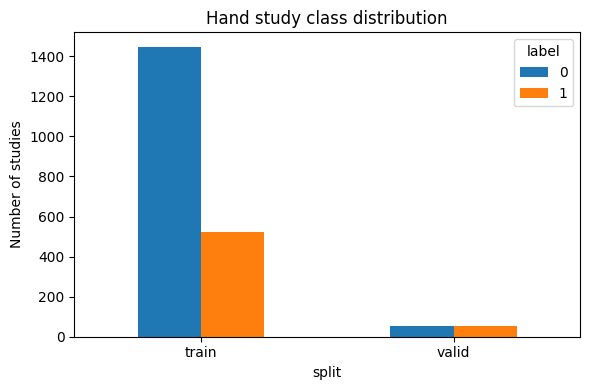

label     0    1
split           
train  1447  521
valid    53   52


In [7]:
train_df = pd.read_csv(TRAIN_CSV, header=None, names=["study_path", "label"])
valid_df = pd.read_csv(VALID_CSV, header=None, names=["study_path", "label"])
train_df["split"] = "train"
valid_df["split"] = "valid"
all_df = pd.concat([train_df, valid_df], ignore_index=True)

counts = all_df.groupby(["split", "label"]).size().unstack()
counts.plot(kind="bar", figsize=(6, 4))
plt.title("Hand study class distribution")
plt.ylabel("Number of studies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)

## 6. MIL Dataset

In [8]:
class MuraHandMIL(Dataset):
    def __init__(self, csv_file, split, transform=None):
        self.df = pd.read_csv(csv_file, header=None, names=["study_path", "label"])
        self.df = self.df[self.df.study_path.str.contains("XR_HAND")].reset_index(drop=True)
        self.split     = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row.label, dtype=torch.float32)

        # Extract actual split from the path string itself 
        # handles train-origin studies living in the valid CSV after rebalancing
        rel        = row.study_path.replace("MURA-v1.1/", "")  # "train/XR_HAND/patient/study"
        path_split = rel.split("/")[0]                          # "train" or "valid"

        base  = get_split_base(path_split)
        parts = rel.split("/", 2)                               # ["train", "XR_HAND", "patient/study"]
        study_dir = os.path.join(base, parts[2]) if len(parts) == 3 else os.path.join(base, rel)

        images = []
        for fname in sorted(os.listdir(study_dir)):
            if not fname.lower().endswith(".png"):
                continue
            img = cv2.imread(os.path.join(study_dir, fname), cv2.IMREAD_GRAYSCALE)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            if self.transform:
                img = self.transform(img)
            images.append(img)

        return torch.stack(images), label

## 7. Transforms

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(5),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 8. DataLoaders & class weighting

In [10]:
train_ds = MuraHandMIL(TRAIN_CSV, "train", train_tf)
valid_ds = MuraHandMIL(VALID_CSV, "valid", val_tf)

labels             = train_ds.df["label"].values
class_sample_count = np.array([(labels == 0).sum(), (labels == 1).sum()])
weight             = 1.0 / class_sample_count
samples_weight     = torch.from_numpy(np.array([weight[t] for t in labels])).double()
sampler            = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler, num_workers=2)
val_loader   = DataLoader(valid_ds, batch_size=1, shuffle=False,   num_workers=2)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos        = int((labels == 1).sum())
neg        = int((labels == 0).sum())
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Train bags : {len(train_ds)}  |  Valid bags : {len(valid_ds)}")
print(f"Normal: {neg}  |  Abnormal: {pos}  |  pos_weight: {pos_weight.item():.4f}")
print(f"Device: {device}")

Train bags : 1968  |  Valid bags : 105
Normal: 1447  |  Abnormal: 521  |  pos_weight: 2.7774
Device: cpu


## 9. Attention-MIL model (MobileNetV2 backbone)

In [11]:
class AttentionMIL(nn.Module):
    def __init__(self):
        super().__init__()
        backbone               = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.feature_extractor = backbone.features
        self.pool              = nn.AdaptiveAvgPool2d(1)
        self.feat_dim          = 1280
        self.dropout           = nn.Dropout(0.3)
        self.attention         = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )
        self.classifier = nn.Linear(self.feat_dim, 1)

    def forward(self, x):             # x: [1, N, 3, H, W]
        x     = x.squeeze(0)          # [N, 3, H, W]
        feats = self.feature_extractor(x)
        feats = self.pool(feats).view(feats.size(0), -1)   # [N, 1280]
        A     = torch.softmax(self.attention(feats), dim=0)
        bag   = self.dropout(torch.sum(A * feats, dim=0))
        return self.classifier(bag), A

## 10. Training

In [12]:
MAX_BAG_TRAIN = 8
MAX_BAG_VAL   = 12
NUM_EPOCHS    = 20
PATIENCE      = 7

model = AttentionMIL().to(device)

optimizer = torch.optim.AdamW([
    {'params': model.feature_extractor.parameters(), 'lr': 1e-5},
    {'params': model.attention.parameters(),         'lr': 1e-4},
    {'params': model.classifier.parameters(),        'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ── Resume if checkpoint exists ──
resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint_hand.pth")
best_auc    = 0.0
start_epoch = 0
no_improve  = 0

if os.path.exists(resume_path):
    print(f"Resuming from: {resume_path}")
    try:
        ckpt        = torch.load(resume_path, weights_only=False, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_auc    = ckpt.get('best_auc', 0.0)
        no_improve  = ckpt.get('no_improve', 0)
        print(f"Epoch {start_epoch}, best_auc={best_auc:.4f}, no_improve={no_improve}")
    except RuntimeError as e:
        print(f"Incompatible checkpoint ({e}). Starting fresh.")
else:
    print("No checkpoint — starting fresh.")

# ── Loop ──
for epoch in range(start_epoch, NUM_EPOCHS):

    if epoch == 1:
        print("Unfreezing backbone (BN stays frozen)...")
        for p in model.feature_extractor.parameters():
            p.requires_grad = True

    model.train()
    if epoch >= 1:
        for m in model.feature_extractor.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

    train_loss = 0.0
    for bags, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        bags, label = bags.to(device), label.to(device).float()
        if bags.size(1) > MAX_BAG_TRAIN:
            bags = bags[:, torch.randperm(bags.size(1))[:MAX_BAG_TRAIN]]
        pred, _ = model(bags)
        loss = criterion(pred.view(-1), label.view(-1))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for bags, label in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Valid]"):
            bags, label = bags.to(device), label.to(device).float()
            if bags.size(1) > MAX_BAG_VAL:
                n = bags.size(1); s = (n - MAX_BAG_VAL) // 2
                bags = bags[:, s:s + MAX_BAG_VAL]
            pred, _ = model(bags)
            val_loss += criterion(pred.view(-1), label.view(-1)).item()
            all_preds.append(torch.sigmoid(pred).cpu().numpy())
            all_labels.append(label.cpu().numpy())

    val_loss  /= len(val_loader)
    all_preds  = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    auc        = roc_auc_score(all_labels, all_preds)

    print(f"\nEpoch {epoch+1}  Train: {train_loss:.4f}  Val: {val_loss:.4f}  AUC: {auc:.4f}")
    scheduler.step()

    ckpt_state = {
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': best_auc, 'no_improve': no_improve,
    }
    torch.save(ckpt_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint_hand.pth"))

    # update no_improve FIRST
    if auc > best_auc:
        best_auc = auc
        no_improve = 0  # ← reset
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✅ Best model saved → {BEST_MODEL_PATH}  (AUC={best_auc:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("Early stopping!"); break

    # THEN save checkpoint with correct no_improve
    ckpt_state = {
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': best_auc, 'no_improve': no_improve,
    }
    torch.save(ckpt_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint_hand.pth"))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 99.6MB/s]


No checkpoint — starting fresh.


Epoch 1/20 [Valid]: 100%|██████████| 105/105 [00:08<00:00, 13.04it/s]



Epoch 1  Train: 1.0868  Val: 1.1330  AUC: 0.5392
✅ Best model saved → /kaggle/working/best_model_hand.pth  (AUC=0.5392)
Unfreezing backbone (BN stays frozen)...


...


Epoch 13  Train: 0.4287  Val: 1.1647  AUC: 0.8030
  No improvement (5/7)


Epoch 14/20 [Valid]: 100%|██████████| 105/105 [00:07<00:00, 14.96it/s]



Epoch 14  Train: 0.3986  Val: 1.2152  AUC: 0.8204
  No improvement (6/7)


Epoch 15/20 [Valid]: 100%|██████████| 105/105 [00:07<00:00, 15.00it/s]


Epoch 15  Train: 0.3775  Val: 1.2574  AUC: 0.8033
  No improvement (7/7)
Early stopping!


## 11. Evaluation

[WARNING] best_model_hand.pth not found — using current model state.


Inference: 100%|██████████| 105/105 [00:07<00:00, 14.95it/s]



⚠️  Validation set: 53 Normal / 52 Abnormal
    (Metrics below are unreliable if Normal count is very small)

AUC: 0.8033  |  F1-optimal threshold: 0.7400


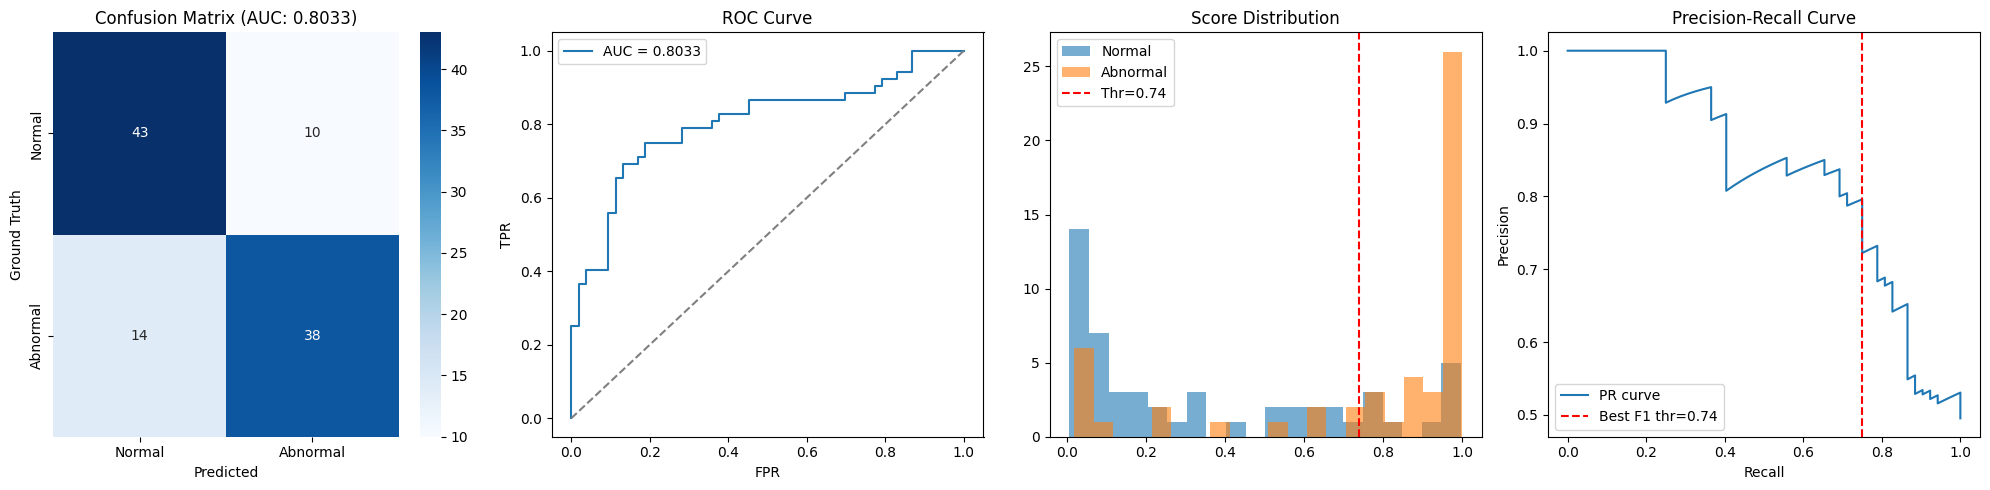

Accuracy    : 0.7714
Precision   : 0.7917
Recall      : 0.7308
Specificity : 0.8113
F1 Score    : 0.7600
              precision    recall  f1-score   support

      Normal       0.75      0.81      0.78        53
    Abnormal       0.79      0.73      0.76        52

    accuracy                           0.77       105
   macro avg       0.77      0.77      0.77       105
weighted avg       0.77      0.77      0.77       105



In [13]:
best_path = os.path.join(CHECKPOINT_DIR, "best_model_hand.pth")
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Best model: epoch {ckpt['epoch']+1}, AUC {ckpt['best_auc']:.4f}")
else:
    print("[WARNING] best_model_hand.pth not found — using current model state.")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for bags, label in tqdm(val_loader, desc="Inference"):
        pred, _ = model(bags.to(device))
        all_preds.append(torch.sigmoid(pred).cpu().numpy())
        all_labels.append(label.numpy())

all_preds  = np.concatenate(all_preds).ravel()
all_labels = np.concatenate(all_labels).ravel()

print(f"\n⚠️  Validation set: {int((all_labels==0).sum())} Normal / {int((all_labels==1).sum())} Abnormal")
print("    (Metrics below are unreliable if Normal count is very small)\n")

# AUC + ROC
from sklearn.metrics import precision_recall_curve
auc_score     = roc_auc_score(all_labels, all_preds)
fpr, tpr, thr = roc_curve(all_labels, all_preds)

# F1-optimal threshold (better than Youden for imbalanced data)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(all_labels, all_preds)
f1_scores = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)
best_thr  = pr_thresholds[np.argmax(f1_scores[:-1])]

binary_preds = (all_preds > best_thr).astype(int)
print(f"AUC: {auc_score:.4f}  |  F1-optimal threshold: {best_thr:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, binary_preds)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
axes[0].set_title(f'Confusion Matrix (AUC: {auc_score:.4f})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Ground Truth')

axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve"); axes[1].legend()

axes[2].hist(all_preds[all_labels==0], bins=20, alpha=0.6, label='Normal')
axes[2].hist(all_preds[all_labels==1], bins=20, alpha=0.6, label='Abnormal')
axes[2].axvline(best_thr, color='red', linestyle='--', label=f'Thr={best_thr:.2f}')
axes[2].set_title("Score Distribution"); axes[2].legend()

# Precision-Recall curve (4th plot — more informative for imbalanced data)
axes[3].plot(recall_vals, precision_vals, label='PR curve')
axes[3].axvline(recall_vals[np.argmax(f1_scores[:-1])], color='red', linestyle='--',
                label=f'Best F1 thr={best_thr:.2f}')
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall Curve"); axes[3].legend()

plt.tight_layout(); plt.show()

accuracy    = (tp+tn)/(tp+tn+fp+fn)
precision   = tp/(tp+fp)  if (tp+fp)>0  else 0
recall      = tp/(tp+fn)  if (tp+fn)>0  else 0
specificity = tn/(tn+fp)  if (tn+fp)>0  else 0
f1          = 2*(precision*recall)/(precision+recall) if (precision+recall)>0 else 0

print("=" * 40)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print("=" * 40)
print(classification_report(all_labels, binary_preds, target_names=['Normal','Abnormal']))

## 13. Visualisation — Attention & Grad-CAM

Picks a random validation bag, displays every instance with its attention score,  
and overlays the Grad-CAM heatmap on the highest-attention image.

In [ ]:
import cv2
import torch.nn.functional as F

def apply_gradcam(model, bag, target_layer, device):
    """
    Grad-CAM on the highest-attention instance of a MIL bag.

    Parameters
    ----------
    model        : AttentionMIL
    bag          : Tensor [1, N, 3, H, W]
    target_layer : nn.Module  — layer to hook (e.g. model.feature_extractor[-1])
    device       : torch.device

    Returns
    -------
    cam          : np.ndarray [224, 224]  normalised heatmap in [0, 1]
    img_tensor   : Tensor     [3, H, W]  denormalised instance (CPU)
    score_attn   : float      attention score of the selected instance
    """
    model.eval()
    features, gradients = [], []

    # ── 1. Hooks ──────────────────────────────────────────────────────────────
    def save_features(module, inp, out):
        features.append(out)

    def save_gradients(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_f = target_layer.register_forward_hook(save_features)
    handle_g = target_layer.register_full_backward_hook(save_gradients)

    try:
        # ── 2. Attention pass (no grad needed) ────────────────────────────────
        with torch.no_grad():
            _, attention_weights = model(bag.to(device))
        attn_scores = attention_weights.cpu().numpy().flatten()
        idx = int(np.argmax(attn_scores))

        # ── 3. Grad-CAM forward on the winning instance ───────────────────────
        input_tensor = bag[0, idx:idx+1].to(device).detach().requires_grad_(True)

        output_features = model.feature_extractor(input_tensor)          # [1, C, h, w]
        pooled          = model.pool(output_features).view(1, -1)        # [1, 1280]
        score           = torch.sigmoid(model.classifier(pooled))        # [1, 1]

        # ── 4. Backward ───────────────────────────────────────────────────────
        model.zero_grad()
        score.backward()

        if not gradients or not features:
            print("Warning: hooks did not fire — check target_layer.")
            return None, None, None

        # ── 5. Build CAM ──────────────────────────────────────────────────────
        grads   = gradients[0].cpu().data.numpy()[0]   # [C, h, w]
        fmaps   = features[0].cpu().data.numpy()[0]    # [C, h, w]
        weights = np.mean(grads, axis=(1, 2))          # [C]

        cam = np.maximum((weights[:, None, None] * fmaps).sum(0), 0)  # [h, w]
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, input_tensor.detach().cpu().squeeze(0), float(attn_scores[idx])

    finally:
        handle_f.remove()
        handle_g.remove()


In [1]:
import random

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])
model = AttentionMIL().to(device)
def denorm(tensor):
    """Denormalise a [3, H, W] tensor → [H, W, 3] float32 in [0, 1]."""
    img = tensor.permute(1, 2, 0).numpy()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)


def visualize_study_attention(model, bag, label, device):
    """
    Row 1 — all instances in the bag, titled with their attention score
             (highest-attention title is red).
    Row 2 — single Grad-CAM overlay for the highest-attention instance.
    """
    model.eval()

    # ── Attention inference ───────────────────────────────────────────────────
    with torch.no_grad():
        logits, attention_weights = model(bag.to(device))
        attn_scores = attention_weights.cpu().numpy().flatten()
        prob        = torch.sigmoid(logits).item()

    num_images = bag.shape[1]
    images     = bag.squeeze(0).cpu()          # [N, 3, H, W]
    best_idx   = int(np.argmax(attn_scores))
    true_label = int(label.item()) if hasattr(label, "item") else int(label)

    pred_str = "FRACTURE" if prob > 0.35 else "SAIN"
    true_str = "Fracture" if true_label == 1 else "Sain"

    # ── Grad-CAM for the best instance ───────────────────────────────────────
    target_layer = model.feature_extractor[-1]
    cam, _, score_attn = apply_gradcam(model, bag, target_layer, device)

    # ── Layout: 2 rows — top: all instances, bottom: Grad-CAM ────────────────
    fig = plt.figure(figsize=(max(15, num_images * 3), 8))
    fig.suptitle(
        f"Résultat: {pred_str} (prob={prob:.4f})  |  Réalité: {true_str}",
        fontsize=14, fontweight="bold"
    )

    # -- Row 1: all instances -------------------------------------------------
    for i in range(num_images):
        ax = fig.add_subplot(2, max(num_images, 2), i + 1)
        ax.imshow(denorm(images[i]))
        color = "red" if i == best_idx else "black"
        ax.set_title(f"Attn: {attn_scores[i]:.4f}", color=color,
                     fontsize=9, fontweight="bold")
        ax.axis("off")

    # -- Row 2: Grad-CAM overlay on the best instance -------------------------
    ax_cam = fig.add_subplot(2, 1, 2)
    if cam is not None:
        raw       = denorm(images[best_idx])                                   # [H,W,3]
        heatmap   = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)  # BGR
        heatmap   = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0          # RGB [0,1]
        overlay   = np.clip(0.6 * raw + 0.4 * heatmap, 0, 1)
        ax_cam.imshow(overlay)
        ax_cam.set_title(
            f"Grad-CAM — instance #{best_idx}  (attention={score_attn:.4f})",
            fontsize=11
        )
    else:
        ax_cam.text(0.5, 0.5, "Grad-CAM unavailable", ha="center", va="center")
    ax_cam.axis("off")

    plt.tight_layout()
    plt.show()


# ── Run on a random validation bag ───────────────────────────────────────────
all_batches     = list(val_loader)
bag, label      = random.choice(all_batches)
visualize_study_attention(model, bag, label, device)


NameError: name 'np' is not defined

In [ ]:
# ── Final: verify best model saved ──
import os
print("Output files:")
for f in os.listdir("/kaggle/working"):
    fpath = f"/kaggle/working/{f}"
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

from IPython.display import FileLink
FileLink('/kaggle/working/best_model_hand.pth')